# Temperature Regression: Celsius -> Fahrenheit

End-to-end walkthrough: generate noisy temperature measurements, explore them, and fit a linear regression model (`z = w*x + b`) with PyTorch.

## Imports

In [1]:
import csv
import random
import statistics

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

CSV_PATH = "temperature_data.csv"
COLOR_EXACT = "#2a78d6"
COLOR_RANDOMIZED = "#eb6834"
COLOR_EXPERIMENTAL = "#eb6834"
COLOR_FIT = "#2a78d6"

## 1. Generate 11 random temperature measurements (Celsius, -5 to 25)

In [2]:
random.seed()
celsius = [round(random.uniform(-5, 25), 1) for _ in range(11)]
celsius

[10.7, 23.1, -1.5, -1.4, 13.8, 21.7, 14.4, 1.1, 6.0, -4.3, 17.5]

## 2. Convert each Celsius value to Fahrenheit

In [3]:
fahrenheit = [round(c * 9 / 5 + 32, 1) for c in celsius]
fahrenheit

[51.3, 73.6, 29.3, 29.5, 56.8, 71.1, 57.9, 34.0, 42.8, 24.3, 63.5]

## 3. Randomize the Fahrenheit values by one standard deviation

Adds Gaussian noise (mean 0, std = the sample standard deviation of the Fahrenheit column) to simulate noisy measurements.

In [4]:
std = statistics.stdev(fahrenheit)
fahrenheit_randomized = [round(v + random.gauss(0, std), 1) for v in fahrenheit]
print("std:", std)
fahrenheit_randomized

std: 17.575116707229206


[42.6, 88.7, -13.6, 39.3, 58.3, 90.6, 67.5, 34.3, 56.0, 17.9, 72.1]

## 4. Save the dataset to CSV

In [5]:
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "point",
        "temperature_celsius",
        "temperature_fahrenheit",
        "temperature_fahrenheit_randomized",
    ])
    for i, (c, f_exact, f_rand) in enumerate(
        zip(celsius, fahrenheit, fahrenheit_randomized), start=1
    ):
        writer.writerow([i, c, f_exact, f_rand])

print(f"Saved {CSV_PATH}")

Saved temperature_data.csv


## 5. Plot the relationship between Celsius and Fahrenheit

The exact conversion line, plus the randomized values scattered around it as a noisy "cloud".

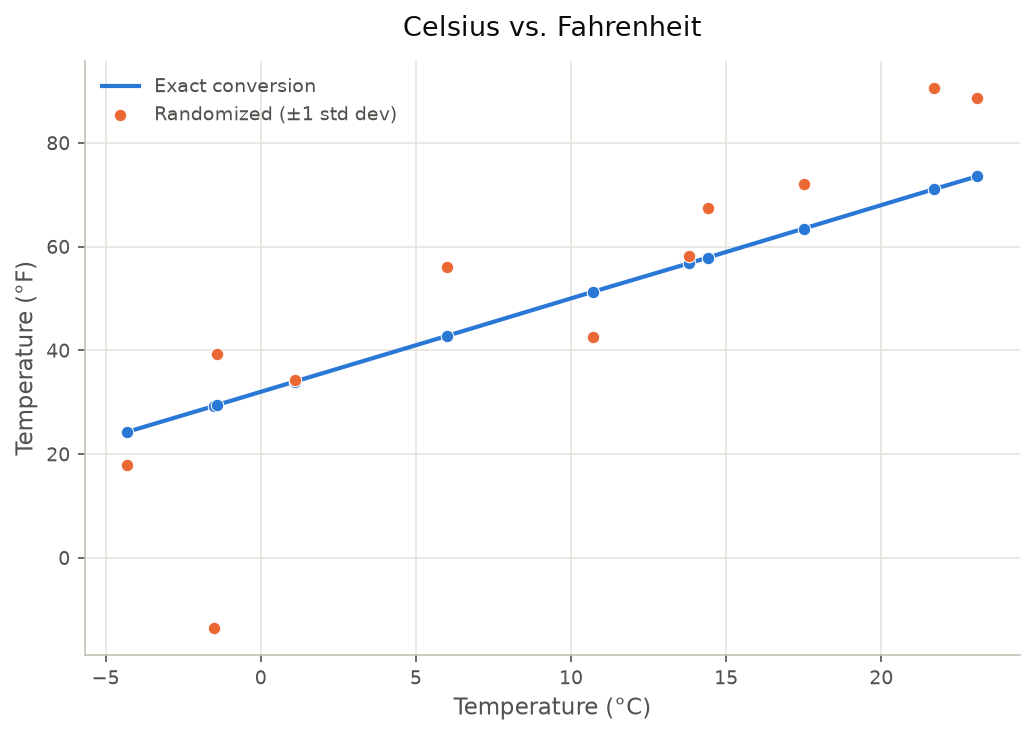

In [6]:
order = sorted(range(len(celsius)), key=lambda i: celsius[i])
celsius_sorted = [celsius[i] for i in order]
fahrenheit_sorted = [fahrenheit[i] for i in order]

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

ax.plot(celsius_sorted, fahrenheit_sorted, color=COLOR_EXACT, linewidth=2,
        zorder=2, label="Exact conversion")
ax.scatter(celsius, fahrenheit, color=COLOR_EXACT, s=36, zorder=3,
           edgecolors="white", linewidths=0.5, label="_nolegend_")
ax.scatter(celsius, fahrenheit_randomized, color=COLOR_RANDOMIZED, s=36,
           zorder=3, edgecolors="white", linewidths=0.5,
           label="Randomized (\u00b11 std dev)")

ax.legend(frameon=False, fontsize=9, labelcolor="#52514e", loc="upper left")
ax.set_title("Celsius vs. Fahrenheit", fontsize=13, color="#0b0b0b", pad=12)
ax.set_xlabel("Temperature (\u00b0C)", fontsize=11, color="#52514e")
ax.set_ylabel("Temperature (\u00b0F)", fontsize=11, color="#52514e")
ax.grid(True, color="#e5e4de", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#52514e", labelsize=9)

fig.tight_layout()
plt.show()

## 6. Present the data as NumPy arrays

`X_train` holds the Celsius values; `y_train` holds the randomized Fahrenheit measurements.

In [7]:
X_train = np.array(celsius)
y_train = np.array(fahrenheit_randomized)
print("X_train:", X_train)
print("y_train:", y_train)

X_train: [10.7 23.1 -1.5 -1.4 13.8 21.7 14.4  1.1  6.  -4.3 17.5]
y_train: [ 42.6  88.7 -13.6  39.3  58.3  90.6  67.5  34.3  56.   17.9  72.1]


## 7. Standardize the Celsius data and convert to PyTorch tensors

In [8]:
X_train_norm = torch.tensor(
    (X_train - X_train.mean()) / X_train.std(), dtype=torch.float32
)
y_train = torch.tensor(y_train, dtype=torch.float32)
print("X_train_norm:", X_train_norm)
print("y_train:", y_train)

X_train_norm: 

tensor([ 0.1621,  1.4938, -1.1481, -1.1374,  0.4950,  1.3434,  0.5594, -0.8689,
        -0.3427, -1.4488,  0.8923])
y_train: tensor([ 42.6000,  88.7000, -13.6000,  39.3000,  58.3000,  90.6000,  67.5000,
         34.3000,  56.0000,  17.9000,  72.1000])


## 8. Create the TensorDataset and DataLoader

In [9]:
train_ds = TensorDataset(X_train_norm, y_train)
train_dl = DataLoader(train_ds, batch_size=1)
len(train_ds)

11

## 9. Define the linear regression model: z = w*x + b

In [10]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.w * x + self.b


model = LinearRegressionModel()
model

LinearRegressionModel()

## 10. MSE loss, SGD optimizer, and the training loop

In [11]:
LEARNING_RATE = 0.01
EPOCHS = 100

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for batch_X, batch_y in train_dl:
        optimizer.zero_grad()
        z = model(batch_X)
        loss = loss_fn(z, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d}  loss {epoch_loss / len(train_dl):.4f}")

print("w:", model.w.item(), "b:", model.b.item())

epoch   0  loss 2998.1416
epoch  10  loss 217.2084
epoch  20  loss 188.7988
epoch  30  loss 188.7554
epoch  40  loss 188.7840
epoch  50  loss 188.7874
epoch  60  loss 188.7878
epoch  70  loss 188.7878
epoch  80  loss 188.7878
epoch  90  loss 188.7878
epoch  99  loss 188.7878
w: 25.97205924987793 b: 50.78284454345703


## 11. Plot the fitted model against the experimental data

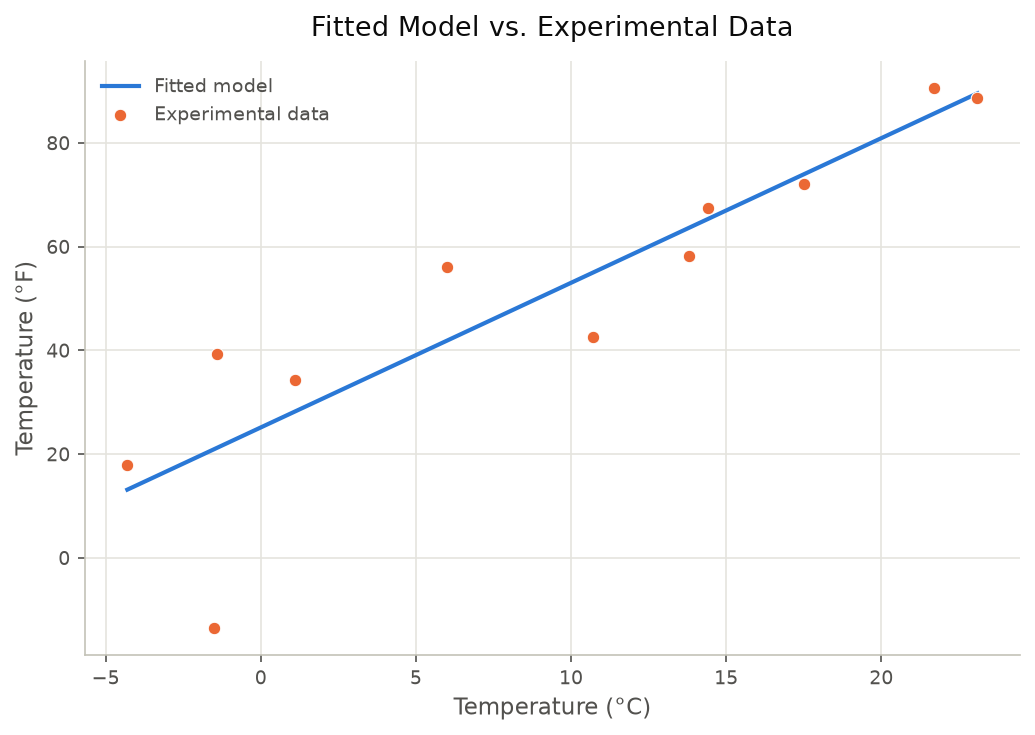

In [12]:
with torch.no_grad():
    z = model(X_train_norm).numpy()

order = sorted(range(len(X_train)), key=lambda i: X_train[i])
celsius_sorted = X_train[order]
z_sorted = z[order]

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

ax.plot(celsius_sorted, z_sorted, color=COLOR_FIT, linewidth=2, zorder=2,
        label="Fitted model")
ax.scatter(X_train, y_train.numpy(), color=COLOR_EXPERIMENTAL, s=36, zorder=3,
           edgecolors="white", linewidths=0.5, label="Experimental data")

ax.set_title("Fitted Model vs. Experimental Data", fontsize=13, color="#0b0b0b", pad=12)
ax.set_xlabel("Temperature (\u00b0C)", fontsize=11, color="#52514e")
ax.set_ylabel("Temperature (\u00b0F)", fontsize=11, color="#52514e")
ax.grid(True, color="#e5e4de", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#52514e", labelsize=9)
ax.legend(frameon=False, fontsize=9, labelcolor="#52514e", loc="upper left")

fig.tight_layout()
plt.show()